In [1]:
from qil_Rigol.rigol import cRigol
import matplotlib.pyplot as plt
import numpy as np

# Arbitrary Commands
A Handy wrapper for when your reading the manual

In [ ]:
import os 
import sys

modulePath = os.path.abspath(os.path.join('..'))
if modulePath not in sys.path:
    sys.path.append(modulePath)

In [14]:
import drivers3.laserHelpers as lhzz

In [16]:
lhzz.get_laser_wavelength(laserIP = '10.196.50.22')

1518.0

In [2]:
rigol=cRigol('10.196.50.21')

#set the averages
rigol.send(":ACQ:AVER 8")

#read the averages
print("Averages",rigol.recieve(":ACQ:AVERages?"))

#Most of Acquire actually has a function
rigol.setAcquire(Averages=4)


#Scope was in a weird mode so doesn't want to change the averages but ty

Connected to RIGOL TECHNOLOGIES,MSO5104,MS5A234906950,00.01.03.00.03
 succesfully 
Averages 2

Averages set to :  2



# Reading the screen
This read is limited to 1000 points but is nice and quick.

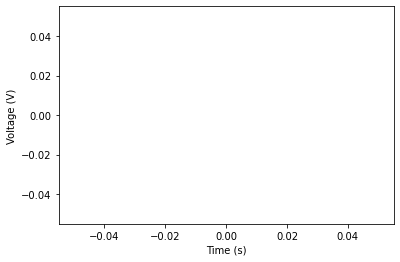

In [ ]:
channels = [2,4]
x,y = rigol.readScreen(channels)

plt.plot(x[0],y[0])
plt.plot(x[1],y[1])
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.show()
plt.close()

# Reading Memory
This reads from the memory but requires stopping the oscilloscope, however we can get many more points

Waiting for Trigger
Trigger Received


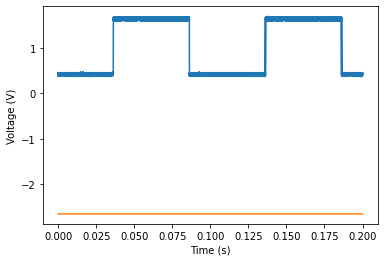

999952


In [ ]:
x,y = rigol.readMemTriggered(channels,pts = "1M")

plt.plot(x[0],y[0])
plt.plot(x[1],y[1])
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.show()
plt.close()
print(len(y[1]))

## Reading without trigger

This is only useful for some signals where there is no clear trigger, i.e. we want to grab data from the laser at a set point.

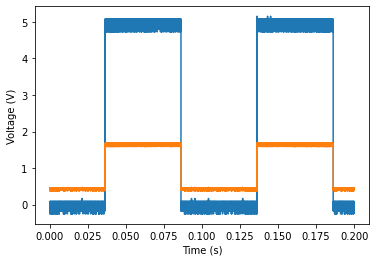

999952


In [ ]:
x,y = rigol.readMem([1,2,3,4],pts = "1M")

plt.plot(x[0],y[0])
plt.plot(x[1],y[1])
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.show()
plt.close()
print(len(y[1]))

In [ ]:

#setup an output on channel 1 with function sine, freq=10, amplitude 1 and offset 0
    #set it as a modulated output
GI=rigol.setSourceOutput(1,"SIN",100,1,0,otype="MOD")



try:
    GI.setSymmetry(30)
except AttributeError:
    print("This will throw an error unless we are a ramp")

#setup modulation settings
try:
    GI.setType("FM")
    GI.setFunction("SIN")
    GI.setInternalFrequency(10)
except AttributeError:
    print("These will throw an error unless we are modulated")
GI.enable()



This will throw an error unless we are a ramp


In [ ]:
import time

initial = rigol.recieve(":CHANnel1:OFFSet?")
#initial =-0.5
xs = np.arange(0,1,0.01)#np.linspace(1,2,100)*float(initial)
off= 0.01#float(initial)*0.1
val = float(initial)
yos = []
yis = []
xr= []
rigol.send(":WAVeform:SOURce CHANnel1")
rigol.send(":Waveform:MODE NORM")
#rigol.send(":Waveform:MODE RAW")

for x in xs:
    
    off =np.round(val+x,3) 
    print(str(off))
    rigol.send(":CHANnel1:OFFSet %s"%(str(off)))
    time.sleep(0.5)
    xr.append(float(rigol.recieve(":CHANnel1:OFFSet?")))

    # rigol.waitforTrigger()
    # rigol.send(":RUN")

    pre = rigol.recieve(":WAV:PRE?")
    tok = pre.split(',')
    YORG=int(tok[8])
    yos.append(YORG)
    yis.append(float(tok[7]))
    #val+=off
rigol.send(":CHANnel1:OFFSet %s"%(str(initial)))


-1.32
-1.31
-1.3
-1.29
-1.28
-1.27
-1.26
-1.25
-1.24
-1.23
-1.22
-1.21
-1.2
-1.19
-1.18
-1.17
-1.16
-1.15
-1.14
-1.13
-1.12
-1.11
-1.1
-1.09
-1.08
-1.07
-1.06
-1.05
-1.04
-1.03
-1.02
-1.01
-1.0
-0.99
-0.98
-0.97
-0.96
-0.95
-0.94
-0.93
-0.92
-0.91
-0.9
-0.89
-0.88
-0.87
-0.86
-0.85
-0.84
-0.83
-0.82
-0.81
-0.8
-0.79
-0.78
-0.77
-0.76
-0.75
-0.74
-0.73
-0.72
-0.71
-0.7
-0.69
-0.68
-0.67
-0.66
-0.65
-0.64
-0.63
-0.62
-0.61
-0.6
-0.59
-0.58
-0.57
-0.56
-0.55
-0.54
-0.53
-0.52
-0.51
-0.5
-0.49
-0.48
-0.47
-0.46
-0.45
-0.44
-0.43
-0.42
-0.41
-0.4
-0.39
-0.38
-0.37
-0.36
-0.35
-0.34
-0.33


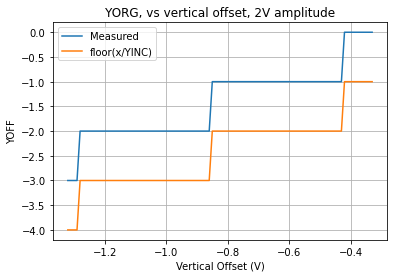

0.42834000000000005 23.345940141009475


In [ ]:

YINC=np.average(yis)
#plt.plot(xs,yis)
plt.plot(val+xs,yos,label="Measured")
plt.plot(val+xs,np.floor((xs+val)/YINC),label="floor(x/YINC)")
plt.grid()
plt.title("YORG, vs vertical offset, 2V amplitude")
plt.xlabel("Vertical Offset (V)")
plt.ylabel("YOFF")
#plt.savefig("Why.png")
plt.legend()
plt.show()
plt.close()

print(YINC,10/YINC)
    #rigol.read(":W")


Offset to YORG when $offset>0$:

    $YORG=floor(\frac{offset}{YINC})$

Offset to $YORG<0$

    $$YORG=\textrm{floor}(\frac{offset}{YINC})+1$$
